# Analysis of Colors in Popular English Romance Movies

## Project Goals: The Colors of Romance

### Introduction
The Colors of Romance project aims to explore the relationship between color palettes and the emotional tone of romance movies across different languages. By analyzing the dominant colors used in popular romance films in English, Korean, and Hindi. This project seeks to uncover whether the language and cultural context influence the color schemes associated with love and romance.

### Whats already done:
**Data Collection:**
Extract frames from the top 25 romance movies in each language category.
Identify the dominant colors in each frame using a consistent methodology.

**Data Organization:**
Store the dominant color data for each movie in separate CSV files, with each file corresponding to one movie.

### What's left to do:

**Color Analysis:**
Perform clustering analysis (e.g., K-Means in this notebook) to identify common color patterns within and across language categories. Compare the color palettes across different languages to see if there are significant differences in how romance is visually represented.

**Visualization:**
Create visual representations (e.g., color histograms, cluster visualizations) to illustrate the dominant colors and patterns found in the analysis.

**Interpretation:**
Interpret the results to draw conclusions about the influence of language and cultural context on the color choices in romance films. Explore whether certain color palettes are more prevalent in one language category compared to others.

**Reporting:**
Document the findings in a comprehensive report, supported by visualizations and statistical analysis.
Discuss potential implications for film studies, cultural analysis, and color theory.

## Imports

In [23]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display, HTML 
import matplotlib.colors as mcolors
import math
from collections import Counter
import matplotlib.cm as cm
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px

## Loading the Datasets

In [24]:

# Path to the directory containing the CSV files
directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/Korean-Analysis/Korean-Movie-CSVs'

# List to hold each DataFrame
dfs = []

# Loop through the files in the directory and load each CSV
for i in range(1, 26):
    file_path = os.path.join(directory_path, f'{i}.csv')
    df = pd.read_csv(file_path)
    # Drop columns with NaN values
    df = df.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    
    # Add a column to indicate which movie the data is from
    df['movie_id'] = i
    
    dfs.append(df)

# Combine all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Display the combined DataFrame to ensure it looks correct
display(combined_df.head())


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,53,53,38,169,195,201,112,123,116,...,130,139,148,76,100,94,116,132,84,1
1,output_0000002.png,106,119,107,150,153,145,38,41,34,...,57,66,41,44,60,55,156,172,156,1
2,output_0000003.png,187,210,188,77,76,71,31,35,36,...,120,139,132,108,92,75,60,84,76,1
3,output_0000004.png,214,228,250,245,245,249,184,202,250,...,186,212,251,188,183,236,215,211,211,1
4,output_0000005.png,117,111,98,17,18,16,172,165,166,...,145,139,148,83,82,85,156,108,94,1


## Initial Visualization

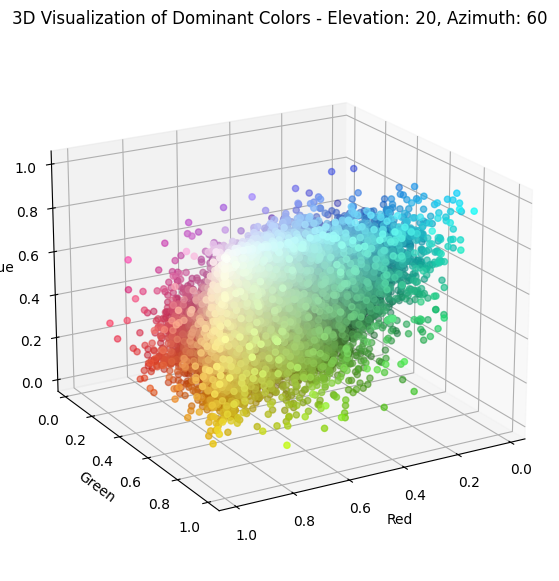

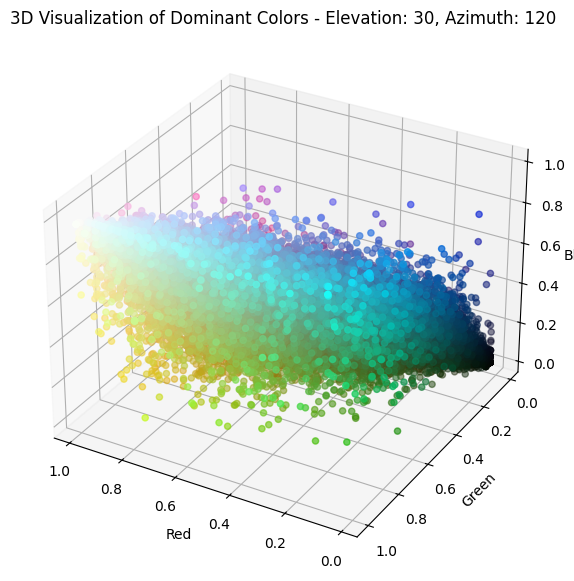

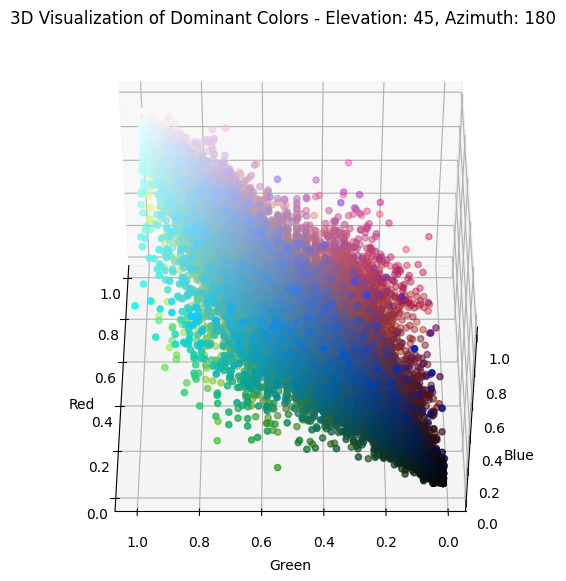

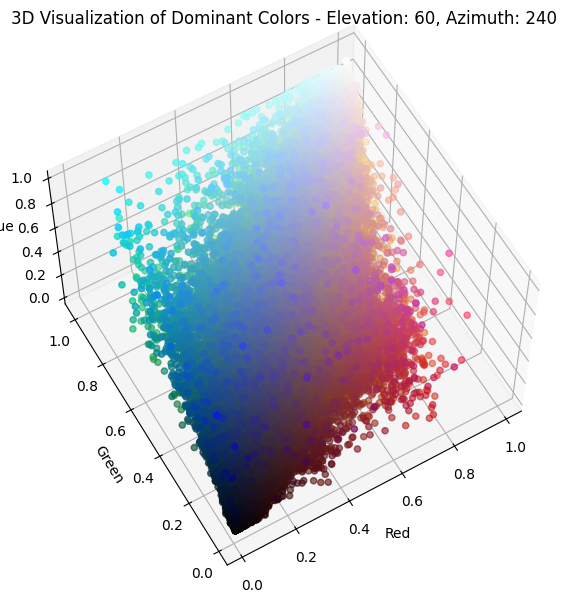

In [25]:
# Create a list of angles to view from
angles = [(20, 60), (30, 120), (45, 180), (60, 240)]

# Extract the RGB values for all 9 dominant colors
r = combined_df[['color_1_r', 'color_2_r', 'color_3_r', 'color_4_r', 'color_5_r', 'color_6_r', 'color_7_r', 'color_8_r', 'color_9_r']].values.flatten()
g = combined_df[['color_1_g', 'color_2_g', 'color_3_g', 'color_4_g', 'color_5_g', 'color_6_g', 'color_7_g', 'color_8_g', 'color_9_g']].values.flatten()
b = combined_df[['color_1_b', 'color_2_b', 'color_3_b', 'color_4_b', 'color_5_b', 'color_6_b', 'color_7_b', 'color_8_b', 'color_9_b']].values.flatten()

# Normalize RGB values and clip to ensure they are within [0, 1]
r_normalized = np.clip(r / 255.0, 0, 1)
g_normalized = np.clip(g / 255.0, 0, 1)
b_normalized = np.clip(b / 255.0, 0, 1)

# Create 3D plots from different angles
for elev, azim in angles:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot
    ax.scatter(r_normalized, g_normalized, b_normalized, c=[(r_val, g_val, b_val) for r_val, g_val, b_val in zip(r_normalized, g_normalized, b_normalized)], marker='o')
    
    # Set labels
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    
    # Set plot title
    ax.set_title(f'3D Visualization of Dominant Colors - Elevation: {elev}, Azimuth: {azim}')
    
    # Set the viewing angle
    ax.view_init(elev=elev, azim=azim)
    
    # Show the plot
    plt.show()

Hmm so from this intial plot it doesnt seem to show us anything indicative of a specific color profile being preferre, but lets not make any conclusions here.

## Dominant Color per frame plotted

Here i just want to plot the dominant color per frame for each movie just to get an idea of what colors i expect to see in the clusterings.

Also to explain, some movies have fewer frames as a result of the scene detect algorithm, which only grabs frames when theres been a significant change in the color profile between frames. Movies where this happens less often, will therefore have fewer frames.

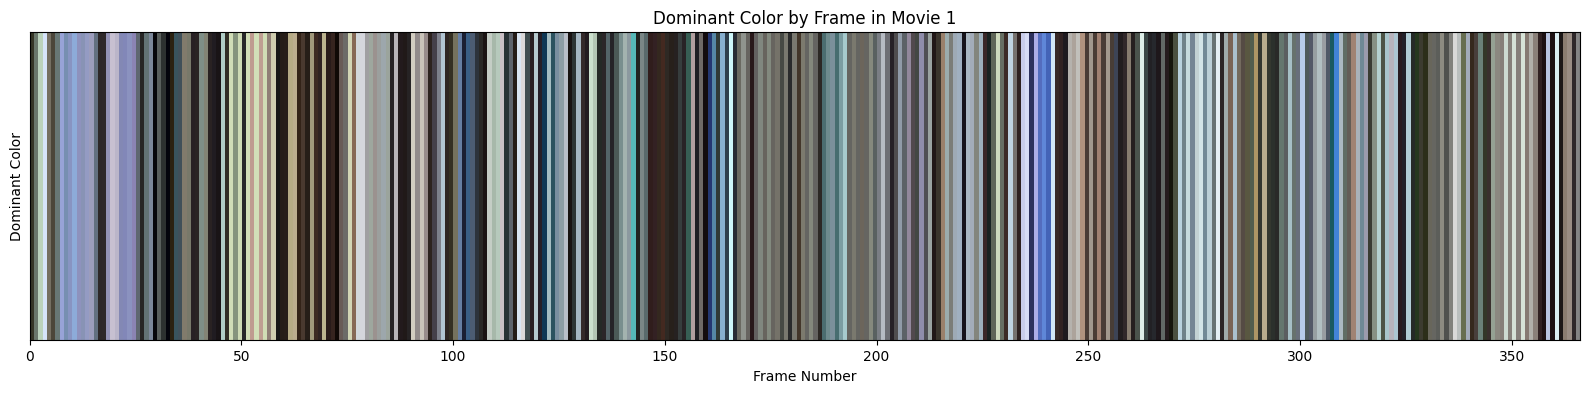

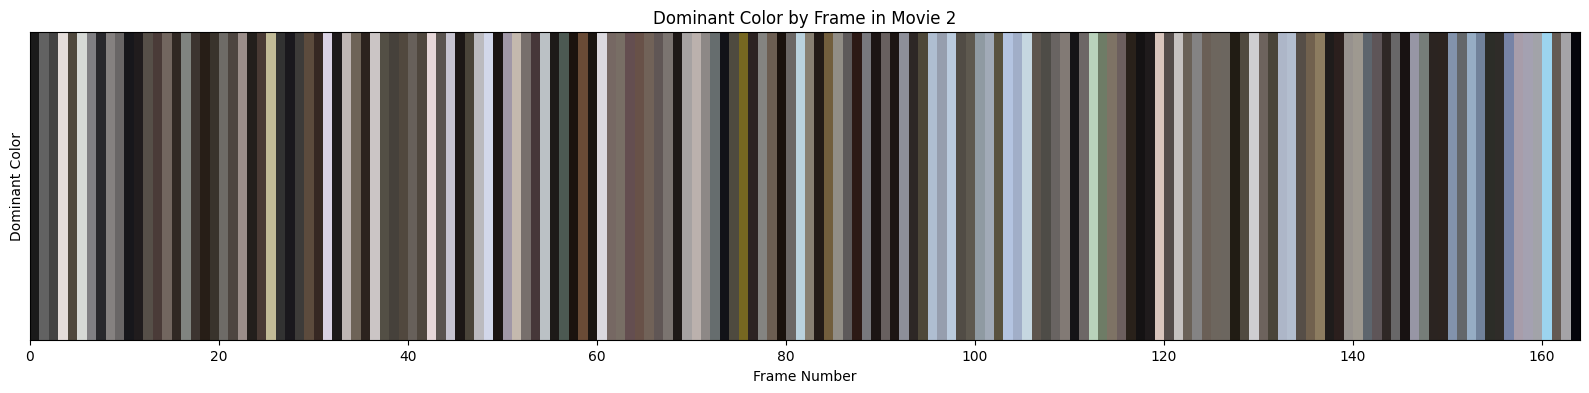

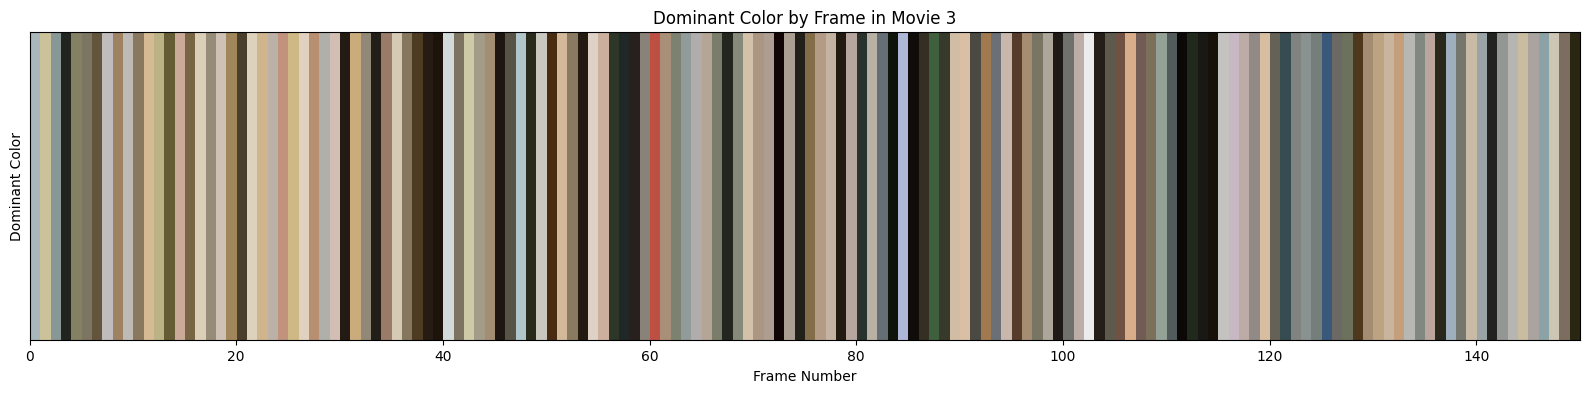

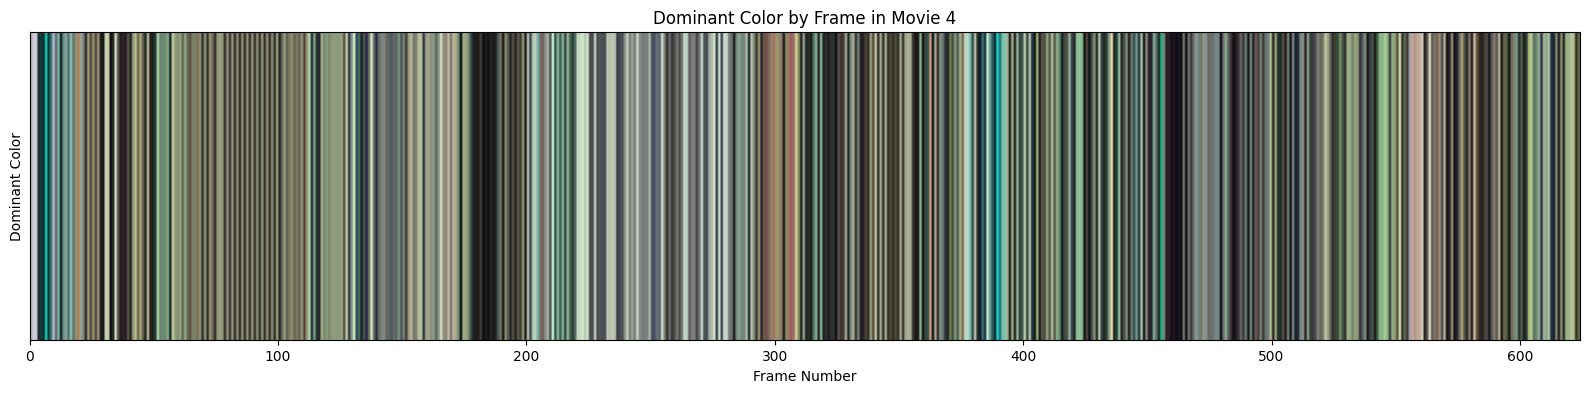

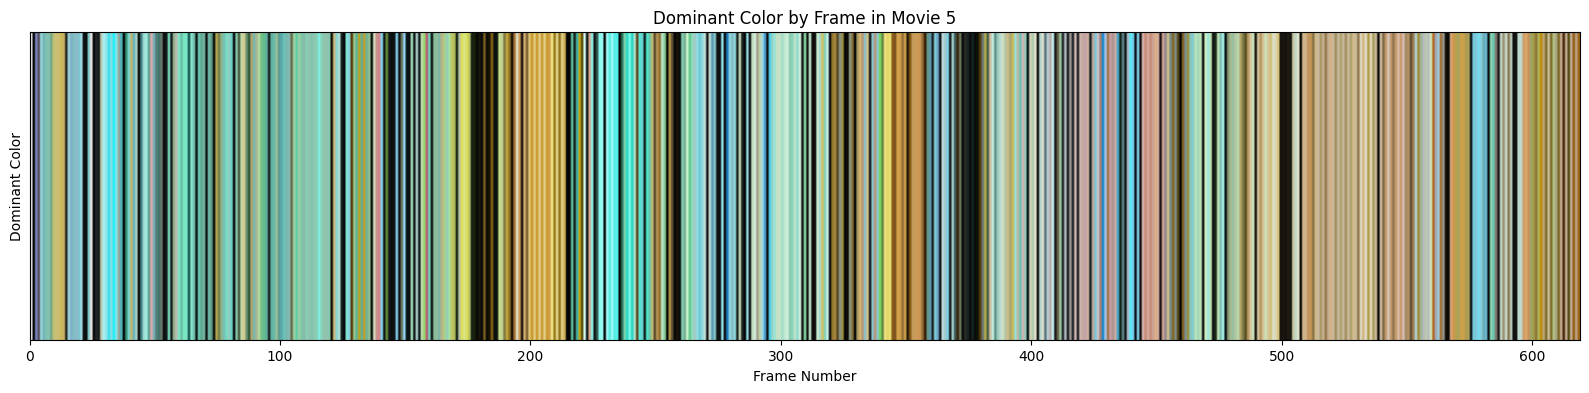

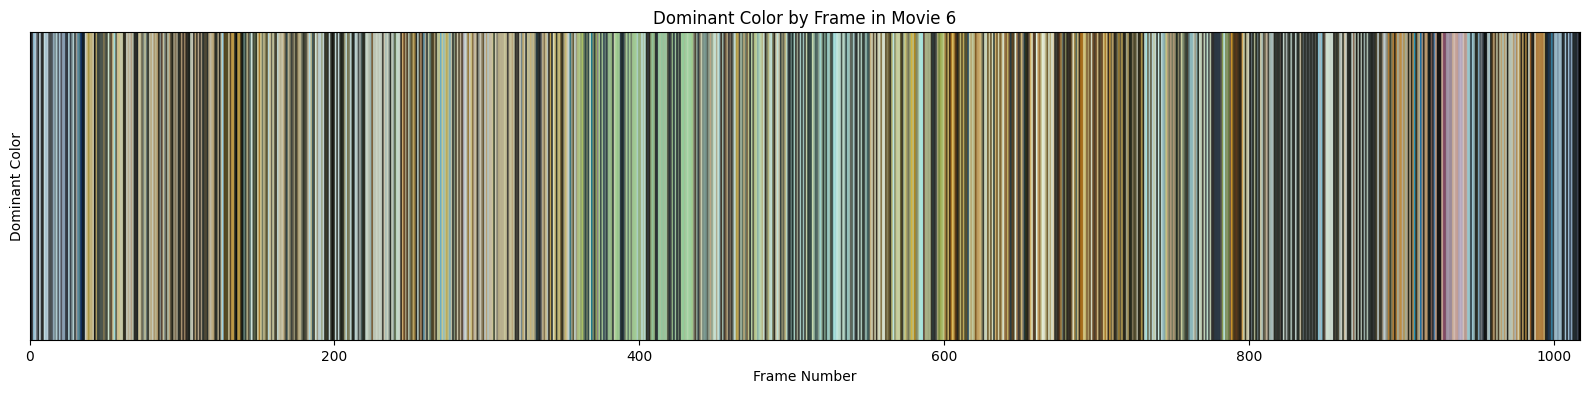

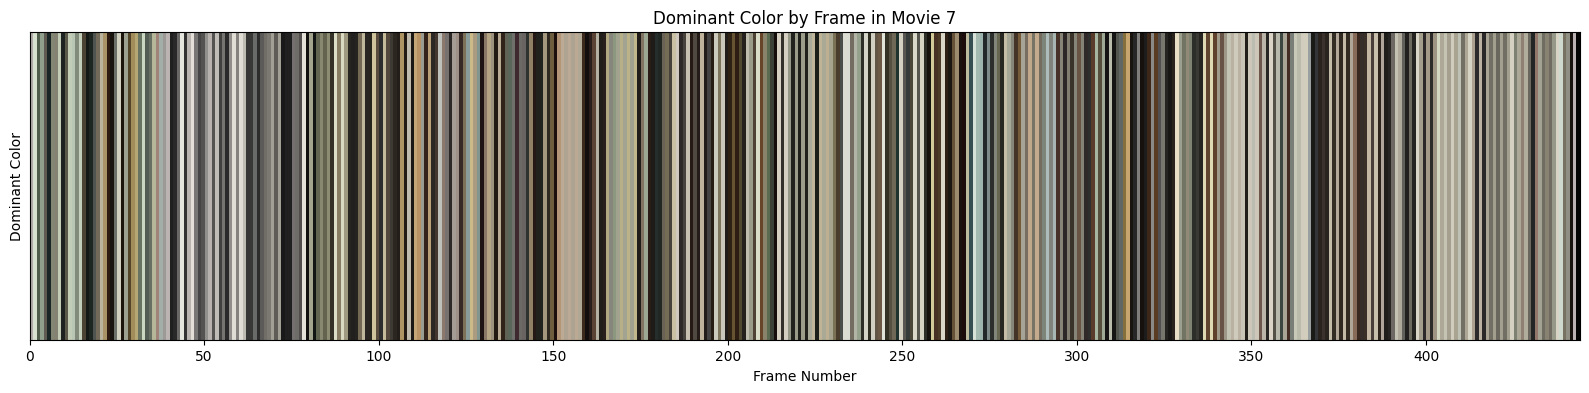

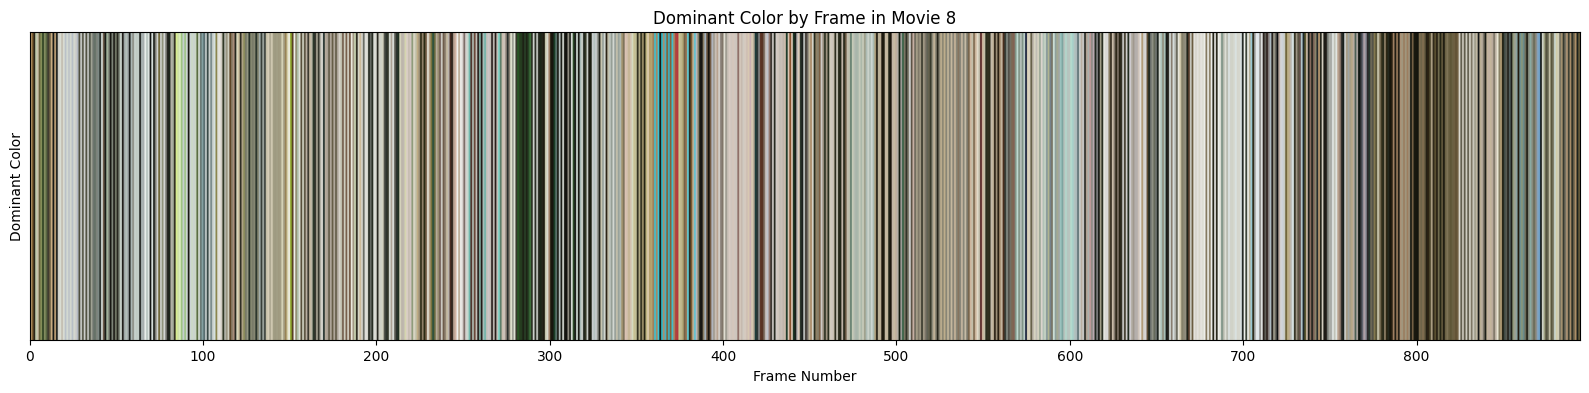

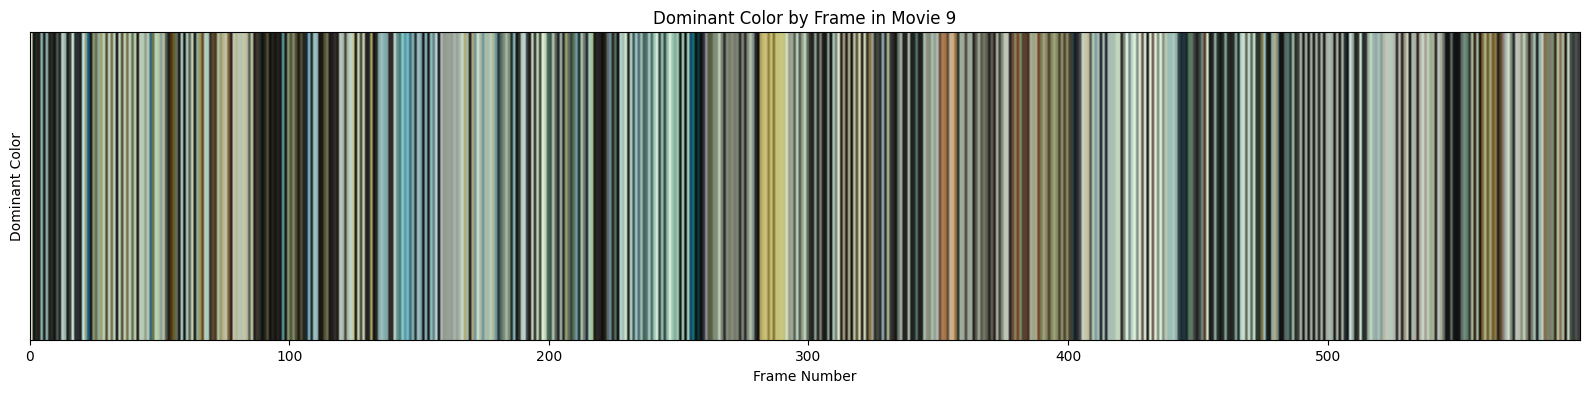

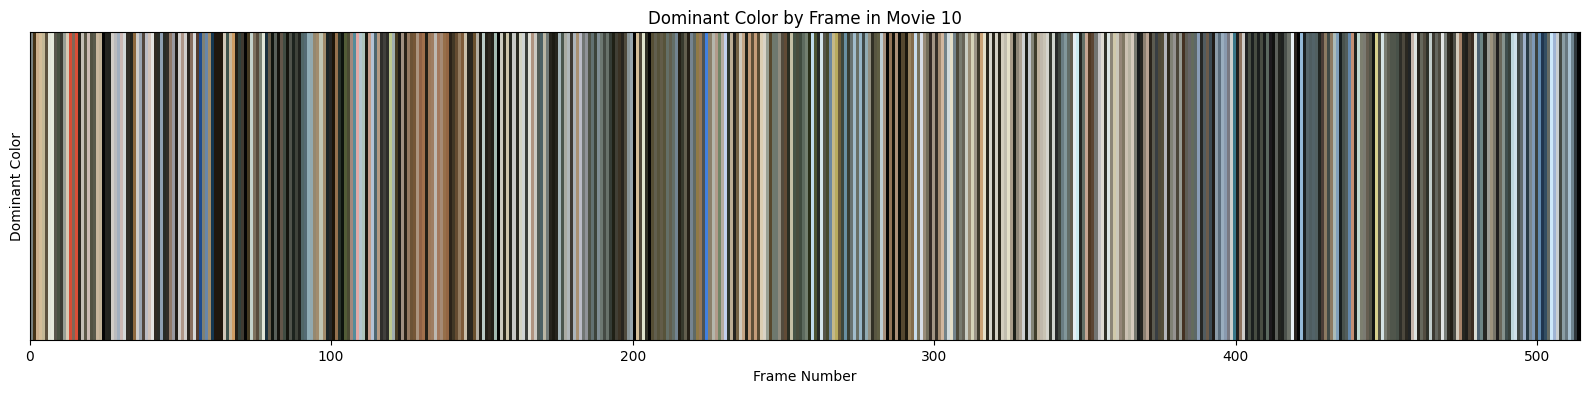

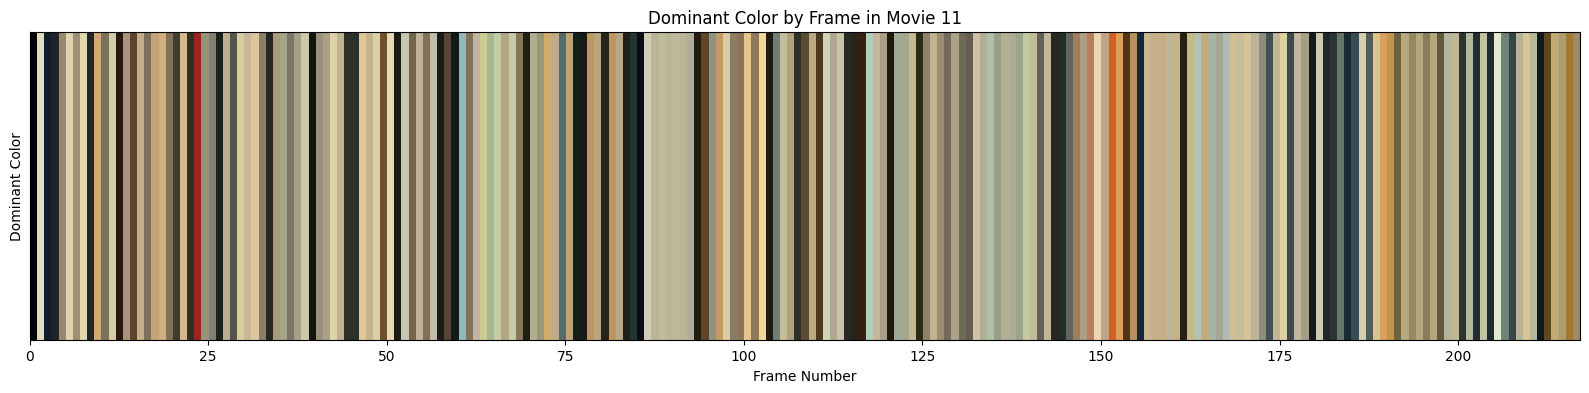

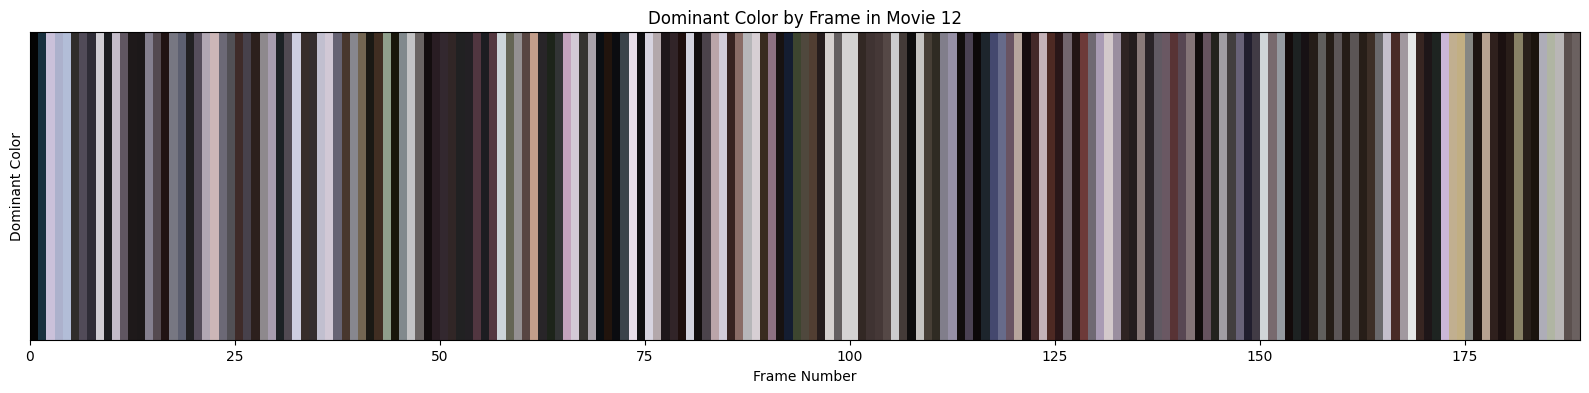

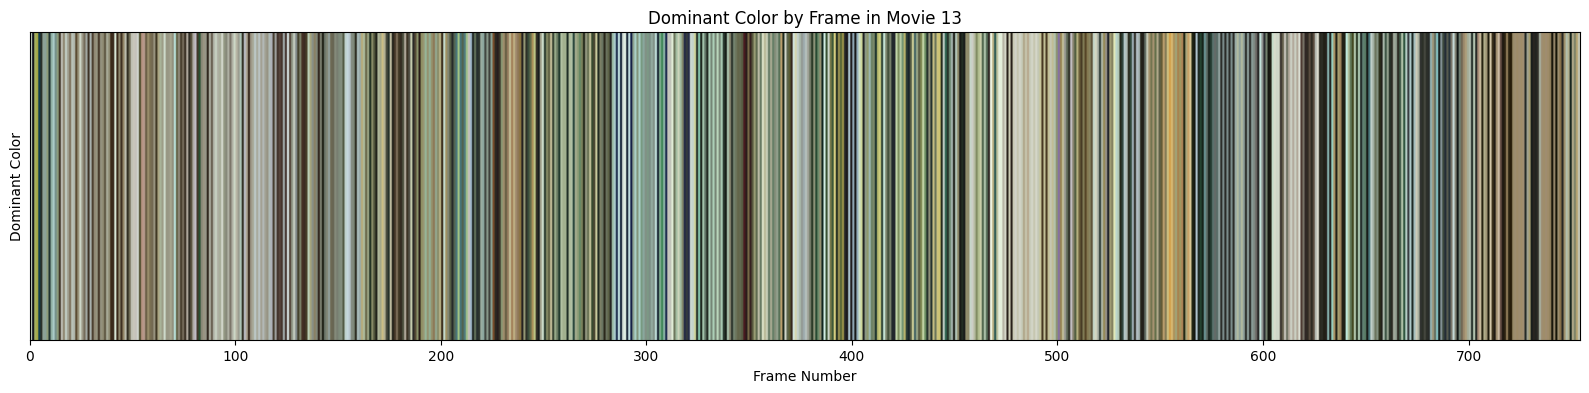

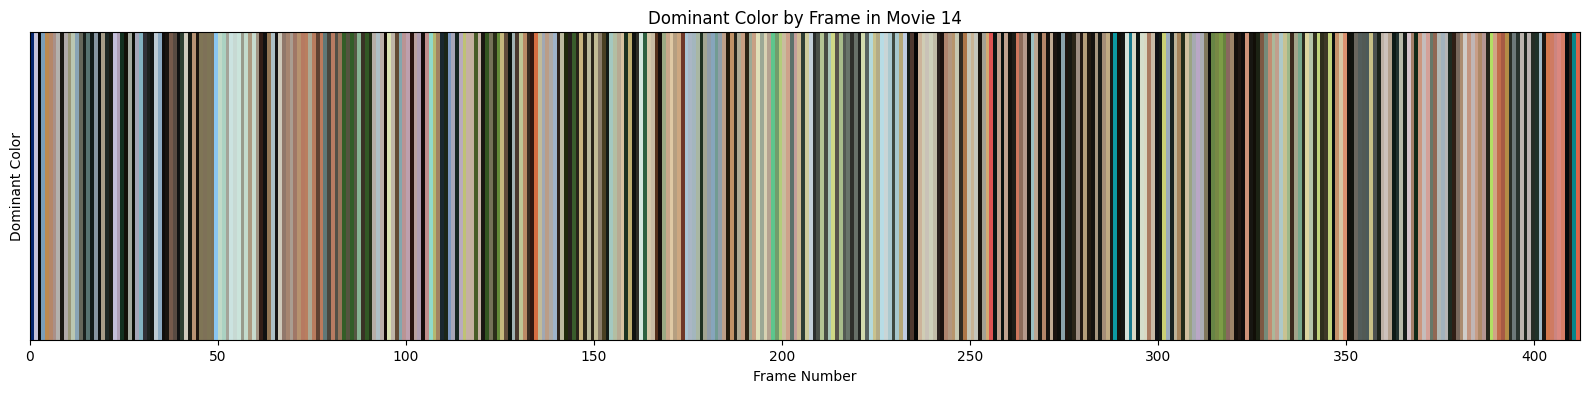

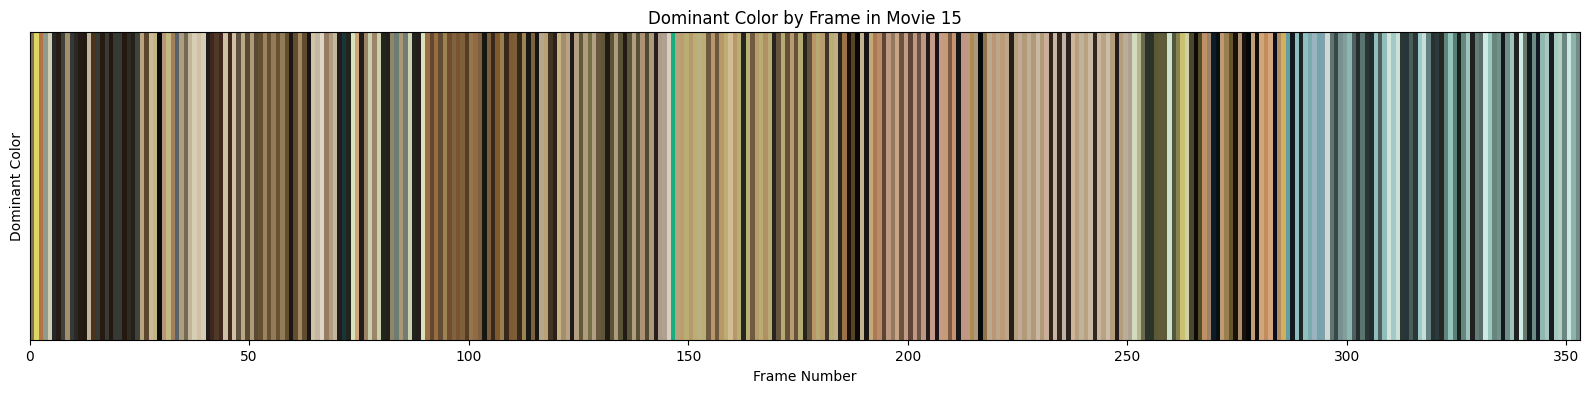

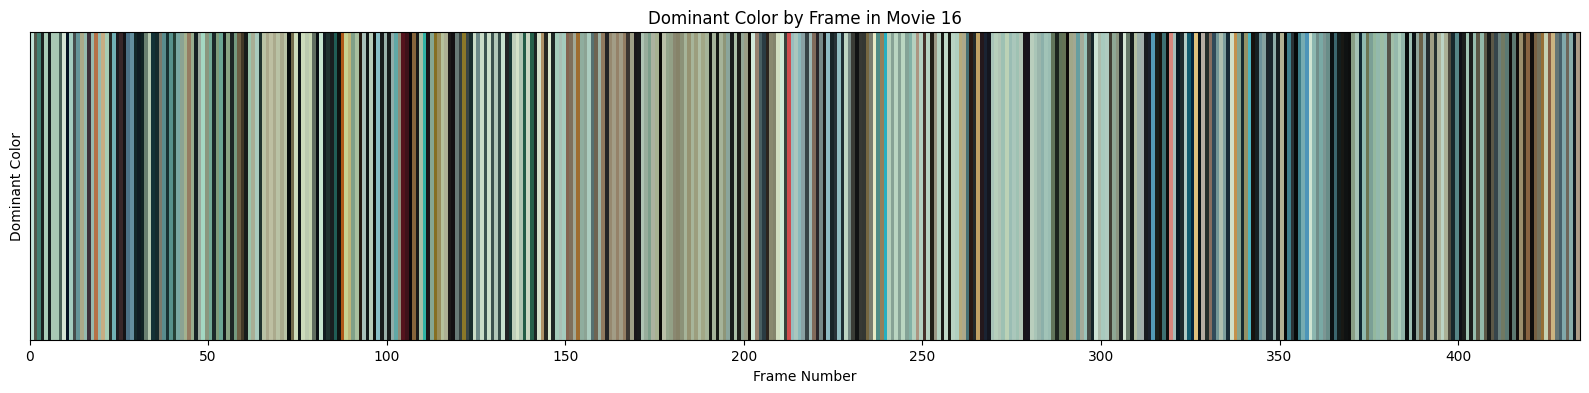

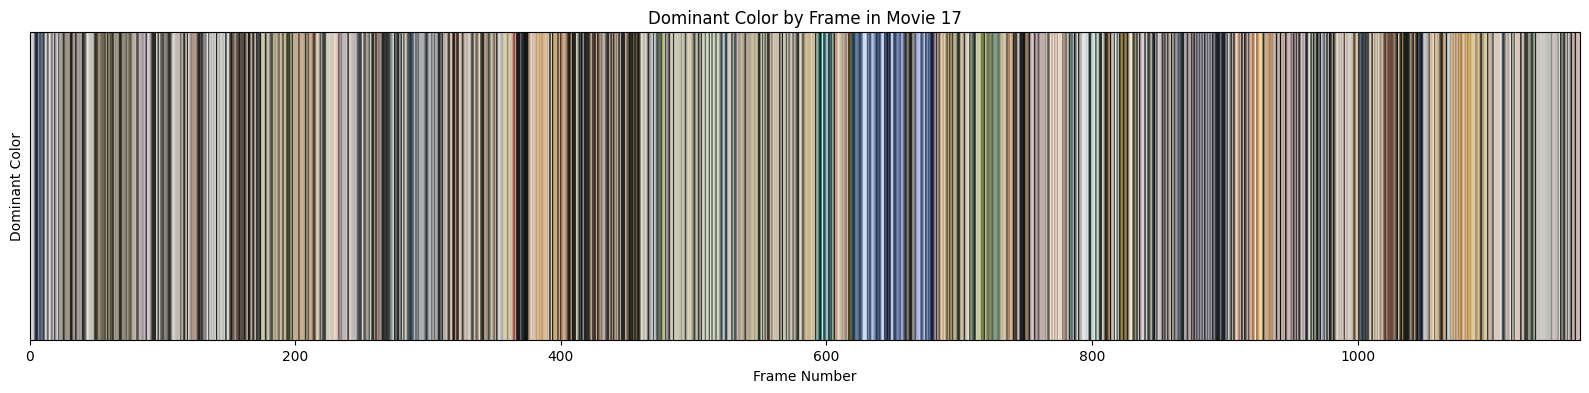

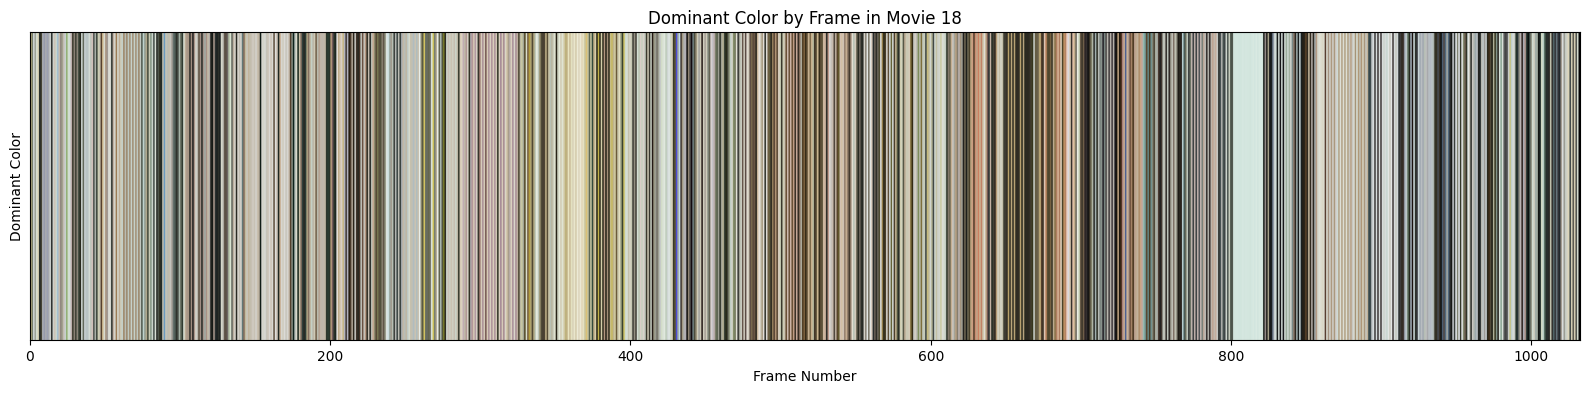

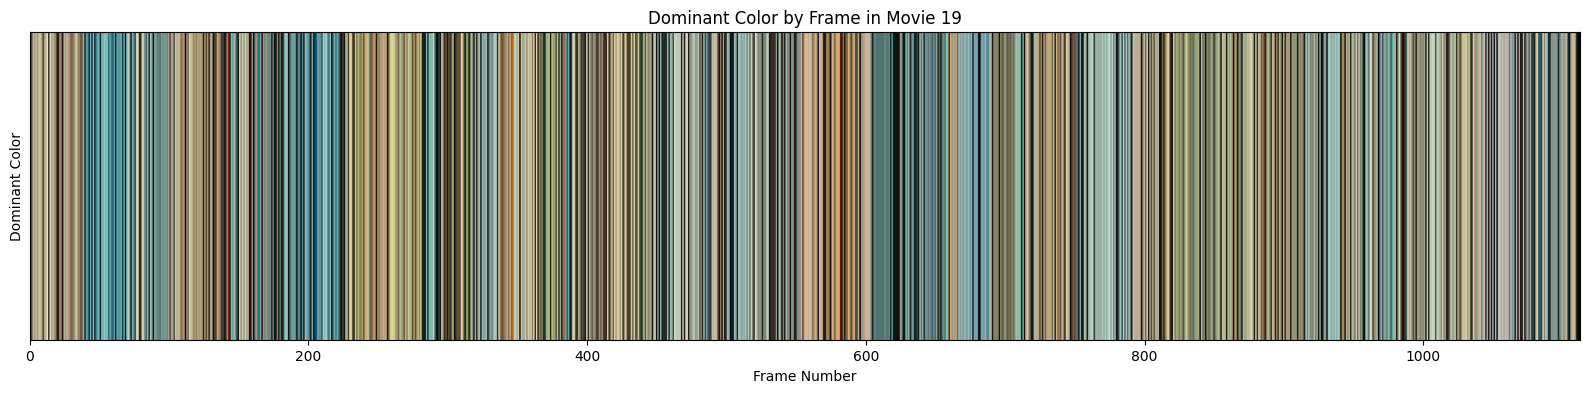

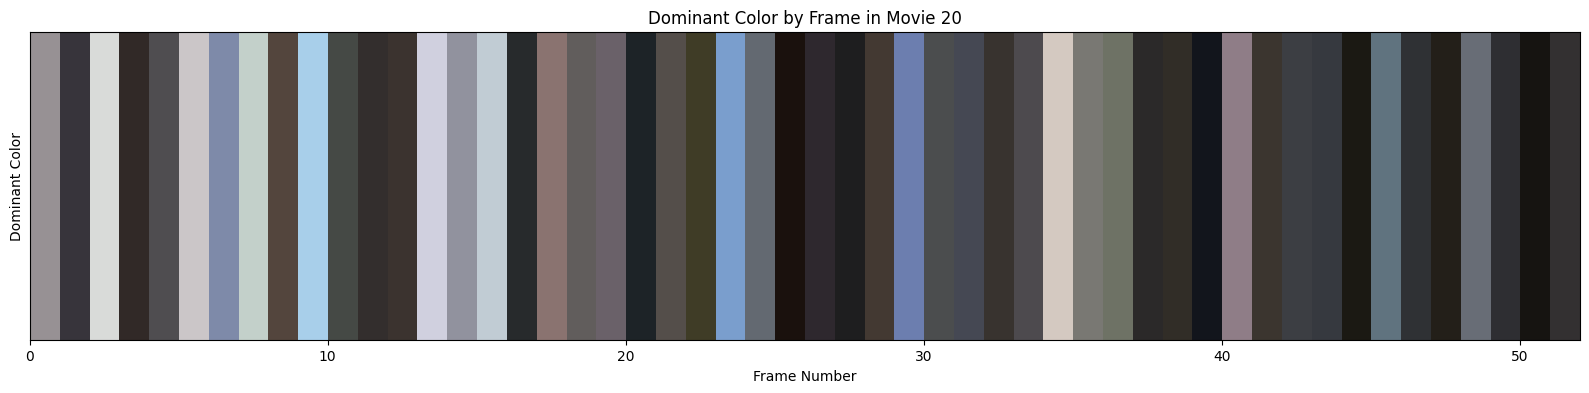

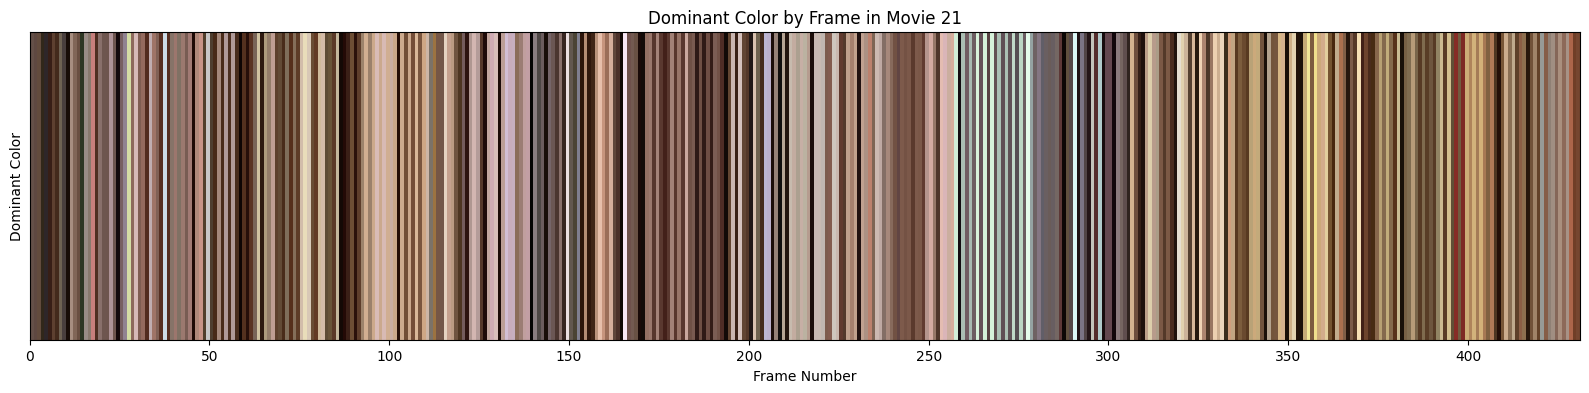

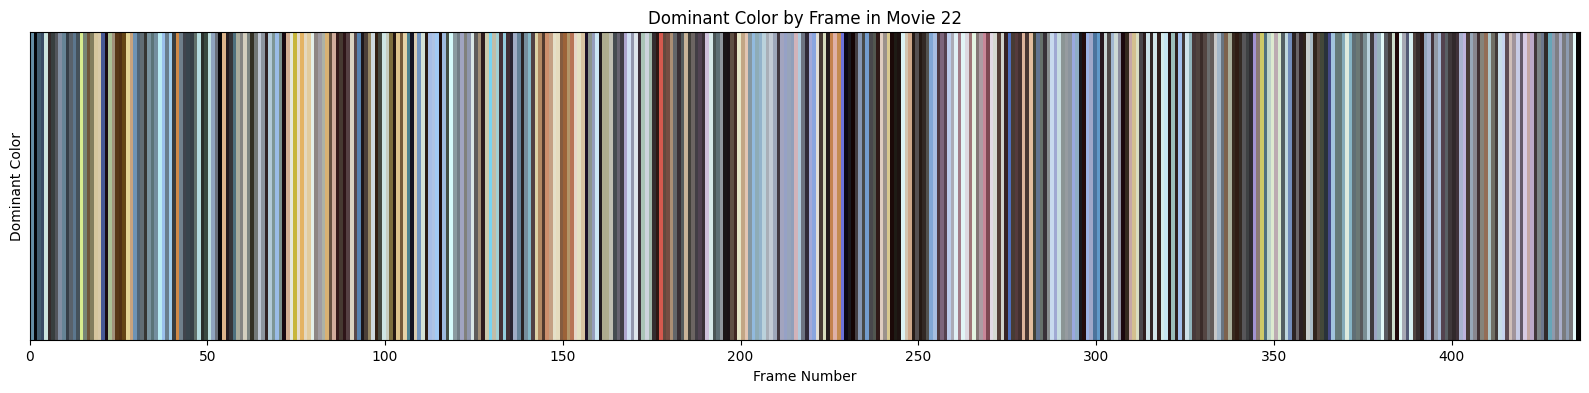

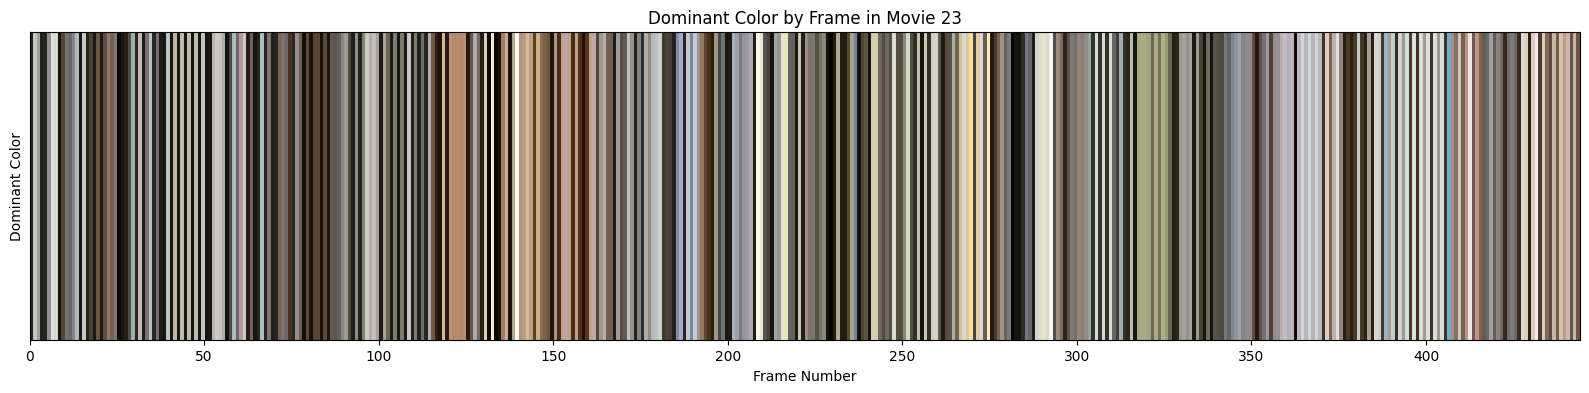

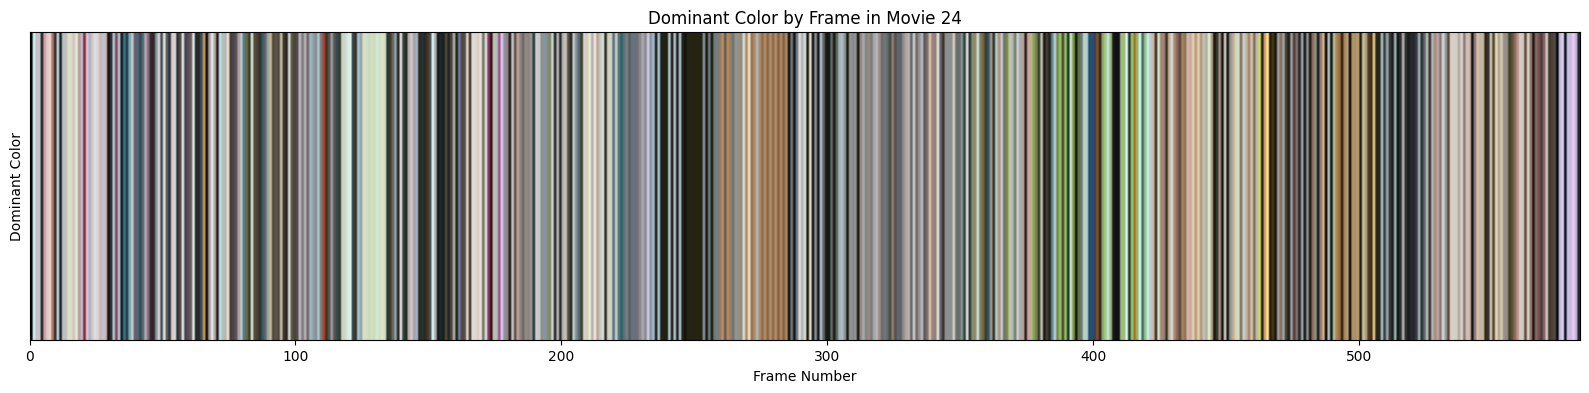

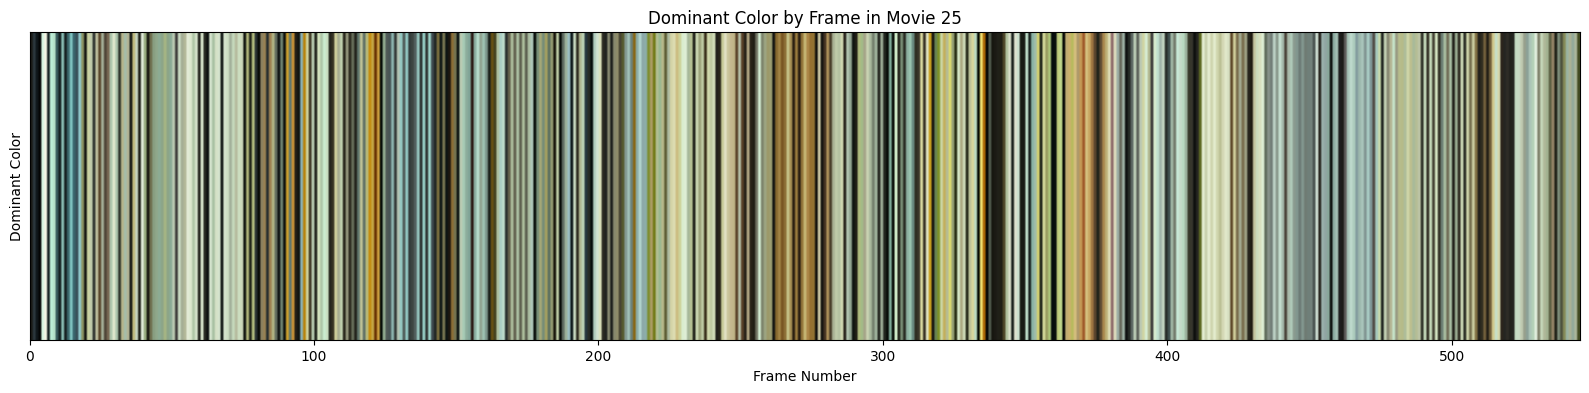

In [26]:
#loop through each movie and plot the dominant color by frame
for movie_id, movie_data in combined_df.groupby('movie_id'):
    # Extract frame numbers and dominant colors for plotting
    frame_numbers = np.arange(len(movie_data))
    dominant_colors_rgb = np.array(movie_data[['color_1_r', 'color_1_g', 'color_1_b']])
    
    # Create the heatmap
    plt.figure(figsize=(20, 4))
    plt.imshow([dominant_colors_rgb], aspect='auto', extent=[0, len(frame_numbers), 0, 1])
    plt.xlabel('Frame Number')
    plt.ylabel('Dominant Color')
    plt.title(f'Dominant Color by Frame in Movie {movie_id}')
    plt.yticks([])
    plt.show()

## K-Means Analysis

I know from the K-means analysis I did on the Ghibli project that the lower the numbers of clusters, the more muted the color of each cluster centre. As stated last time this probably has to do with it averaging more muted tones due to the reduced of clusters. So im going to choose 15 ish clusters.

### The Plan

**Step-by-Step K-Means Analysis:**

1. **Segment Each Movie into x Parts:** We are doing this to get a more diverse understanding of the colors across each movie.

2. **Cluster Colors Within Each Segment:** Apply K-Means clustering to the colors within each segment.

3. **Cluster Segment Centers for Each Movie:** Cluster the cluster centers from each segment to identify dominant color themes for the entire movie.

4. **Final Clustering Across All Movies:** Take the cluster centers from each movie and perform another round of clustering to find common color themes across all movies.

### Step 1: Cluster Colors Within Each Segment

*Segment the movies first*

In [27]:
# Define the number of segments
num_segments = 5

# Loop through each movie and create a segment ID
combined_df['segment_id'] = combined_df.groupby('movie_id').cumcount() // (combined_df.groupby('movie_id')['frame_path'].transform('count') // num_segments)

In [28]:
display(combined_df)

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id,segment_id
0,output_0000001.png,53,53,38,169,195,201,112,123,116,...,139,148,76,100,94,116,132,84,1,0
1,output_0000002.png,106,119,107,150,153,145,38,41,34,...,66,41,44,60,55,156,172,156,1,0
2,output_0000003.png,187,210,188,77,76,71,31,35,36,...,139,132,108,92,75,60,84,76,1,0
3,output_0000004.png,214,228,250,245,245,249,184,202,250,...,212,251,188,183,236,215,211,211,1,0
4,output_0000005.png,117,111,98,17,18,16,172,165,166,...,139,148,83,82,85,156,108,94,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13545,output_0000541.png,155,180,163,31,27,21,99,101,85,...,66,51,152,140,108,68,76,76,25,4
13546,output_0000542.png,172,178,148,27,25,21,95,102,58,...,140,108,124,131,116,75,79,70,25,4
13547,output_0000543.png,147,170,154,16,16,12,87,92,78,...,48,36,121,124,100,52,61,60,25,4
13548,output_0000544.png,172,183,155,28,25,20,101,105,65,...,132,116,132,148,122,75,77,68,25,4


In [29]:
# Group by movie_id and segment_id and count the number of frames in each segment
frame_counts = combined_df.groupby(['movie_id', 'segment_id']).size().reset_index(name='frame_count')

# Display the result
display(frame_counts)

,movie_id,segment_id,frame_count
0,1,0,73
1,1,1,73
2,1,2,73
3,1,3,73
4,1,4,73
...,...,...,...
143,25,0,109
144,25,1,109
145,25,2,109
146,25,3,109


What this tells me is that there are certain segments with very few frames, in this case we can we can add a min_threshold, so lets say if there are less than 5 frames we skip, so less than 50 colors to cluster on. Otherwise we dynamically change the clusters size to match the frames.

In [30]:


# Define the number of clusters for each segment
num_clusters_per_segment = 15  # You can adjust this number

# Define the threshold for the minimum number of frames to perform clustering
# min_frames_threshold = 6  # You can adjust this threshold

# Create a list to hold all cluster centers
all_cluster_centers = []

# Group the data by movie and segment
grouped = combined_df.groupby(['movie_id', 'segment_id'])

for (movie_id, segment_id), group in grouped:
    # Reshape the data to have each color as an individual row
    colors = []
    for i in range(1, 10):  # Looping through the top 9 dominant colors
        colors.append(group[[f'color_{i}_r', f'color_{i}_g', f'color_{i}_b']].dropna().values)

    # Combine all the colors into a single array
    colors_array = np.vstack(colors)

    # Check if there are enough data points to perform clustering
    if len(colors_array) >= num_clusters_per_segment:
        # Perform K-Means clustering on the colors within this segment
        kmeans = KMeans(n_clusters=num_clusters_per_segment,n_init='auto', random_state=42)
        kmeans.fit(colors_array)
        
        # Store the cluster centers
        all_cluster_centers.append(kmeans.cluster_centers_)
    else:
        print(f"Skipping segment {segment_id} of movie {movie_id} due to insufficient data points.")



Skipping segment 5 of movie 1 due to insufficient data points.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning:

Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning:

Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning:

Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.



Skipping segment 5 of movie 21 due to insufficient data points.
Skipping segment 5 of movie 22 due to insufficient data points.


### Visualizing the colors found

In [31]:
# Combine all the cluster centers into a single array
all_cluster_centers = np.vstack(all_cluster_centers)

# Convert RGB values to HEX and HSV
hex_colors = []
hsv_colors = []

for r, g, b in all_cluster_centers:
    hex_color = mcolors.to_hex([r/255, g/255, b/255])
    hsv_color = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    
    hex_colors.append(hex_color)
    hsv_colors.append(hsv_color)

# Sort colors by HSV values (primarily by hue)
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_hex_colors = [hex_colors[i] for i in sorted_indices]

# Set the number of columns in the grid
num_columns = 20 

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_hex_colors) / num_columns)

# Adjust the HTML table to be more responsive
html_table = '<table style="border-collapse: collapse; width:100%;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_hex_colors):
            hex_color = sorted_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:5%; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'


# Display the HTML table
display(HTML(html_table))

# Colors are displayed Left to Right, Top to Bottom.

,#040404,,#040404,,#040404,,#444444,,#b9b6b6,,#343232,,#b69999,,#c49494,,#080404,,#080404,,#080404,,#080404,,#080404,,#080404,,#080404,,#080404,,#080404,,#080404,,#080404,,#863939
,#080404,,#080404,,#080404,,#805050,,#1c1111,,#343333,,#9f4745,,#af4643,,#39302f,,#170d0d,,#4a2f2e,,#1e1c1c,,#955b57,,#be342a,,#a95c56,,#b23f36,,#a49796,,#ac7975,,#373030,,#dabab7
,#cc5246,,#ae5047,,#2b1c1b,,#7d2b23,,#3c2826,,#a5463c,,#383332,,#7c342c,,#c13323,,#1a1515,,#423534,,#382c2b,,#7a706f,,#221716,,#c24535,,#a1483d,,#988784,,#b54638,,#52423f,,#a05c53
,#73615f,,#191413,,#4b413f,,#be301a,,#1d1615,,#b93f2c,,#ab4f40,,#2f2625,,#9d4334,,#aa9c99,,#c2c1c0,,#452620,,#d06e5d,,#150806,,#2d2321,,#b49f9c,,#1f0f0c,,#aa4a38,,#373332,,#b74e3a
,#a54937,,#9a3f2e,,#be4b34,,#463a38,,#4f2a23,,#442620,,#41322f,,#6c534e,,#1a0b08,,#602012,,#4d3d3a,,#83574d,,#5c4c48,,#c05b45,,#160b08,,#978480,,#3a1e17,,#965749,,#a45745,,#be978e
,#dc6347,,#9c675b,,#a1513e,,#bf8c80,,#b36e5d,,#ac6857,,#a35b4a,,#84645c,,#bc5339,,#4b4341,,#ca9b8f,,#b25037,,#9e5f4e,,#7d6c68,,#0f0d0d,,#988782,,#322623,,#dcc6c0,,#ca4b2a,,#6d5b57
,#c5bbb8,,#71615d,,#b56a55,,#51342c,,#a35039,,#6a2d1d,,#4d423f,,#3d3735,,#5a5452,,#c64b28,,#4e2b20,,#864532,,#a19b99,,#8a7169,,#523f3a,,#9f9795,,#1d1513,,#99776e,,#a96754,,#171311
,#1c1513,,#c63e16,,#6c4f47,,#946f64,,#3e2c27,,#7e7b7a,,#5f3427,,#b53d18,,#9a5540,,#45342e,,#63544f,,#1a0c08,,#765c54,,#9a4e35,,#8a8786,,#1b1817,,#865c4e,,#9c6d5e,,#3a2822,,#a4928b
,#9d857d,,#563b31,,#726d6b,,#2d2623,,#433029,,#8c6456,,#795b51,,#512a1c,,#a99289,,#32170d,,#e1a28b,,#a58376,,#a85333,,#a94a27,,#95857e,,#3d2218,,#7a341a,,#a34420,,#64605e,,#1a1412
,#95492b,,#8d7267,,#57382b,,#644f47,,#998881,,#a66146,,#4b3d38,,#767270,,#b66443,,#160c08,,#41322c,,#bab1ae,,#a8958e,,#9f7868,,#c8b2a9,,#a76347,,#b37a63,,#926755,,#a2502f,,#b7481c
,#995e45,,#b6a198,,#ab4c26,,#8e614e,,#ac5632,,#955d45,,#a9755f,,#a6532f,,#6b6664,,#653f2e,,#bc8167,,#563627,,#1e1a18,,#6d5449,,#a25939,,#403b38,,#35231b,,#1a1614,,#796258,,#d4c4be


So it seems that we're seeing almost every color in the spectrum, which is super interesting! But we are visually I am seeing heavier usage of blues, greens, browns and reds more thna anything, but lets check this out with percentages.

### The Plan

To create percentages of the different color tones (e.g., bluish, reddish, yellowish) from the segmented analysis, I plan to follow these steps:

1. **Classify Colors by Tone:** First, classify each color into a tone category (e.g., blue, red, yellow) based on its hue. I can use the HSV (Hue, Saturation, Value)    color space to determine the hue of each color and then categorize it accordingly.

2. **Count the Colors in Each Category:** Once I've classified the colors, I can count how many colors fall into each category.

3. **Calculate Percentages:** Finally, calculate the percentage of each color tone relative to the total number of colors.


**Understanding Hue:**

*Hue:* In the HSV color model, hue represents the type of color (such as red, blue, green, etc.) and is measured as an angle on a color wheel from 0° to 360°.

- 0° corresponds to red.
- 120° corresponds to green.
- 240° corresponds to blue.

The angles in between represent blends of these colors (e.g., 60° is yellow, 180° is cyan).

*Saturation:* Indicates the intensity of the color (from dull/gray to pure color).

*Value:* Represents the brightness of the color.

**Hue Ranges and Corresponding Colors:**

The hue values are typically divided into segments representing different color tones. Here’s how the hue is usually mapped:

- Red: 0° to 30° and 330° to 360°
- Yellow: 30° to 90°
- Green: 90° to 150°
- Cyan: 150° to 210°
- Blue: 210° to 270°
- Magenta: 270° to 330°

### Visualizing the Hue Spectrum

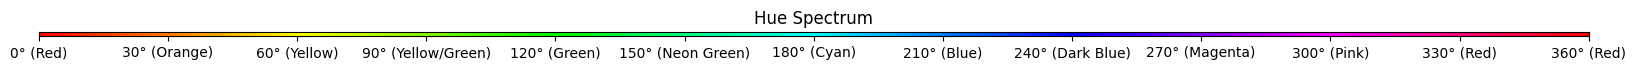

In [32]:
# Generate a spectrum of hues
hues = np.linspace(0, 1, 360)  # 360 values corresponding to hue angles
saturation = np.ones_like(hues)
value = np.ones_like(hues)

# Convert HSV to RGB
hsv_colors = np.stack([hues, saturation, value], axis=1)
rgb_colors = mcolors.hsv_to_rgb(hsv_colors)

# Plot the spectrum
plt.figure(figsize=(20, 2))
plt.imshow([rgb_colors], extent=[0, 360, 0, 1])
plt.yticks([])
plt.xticks(np.arange(0, 361, 30), labels=[
    "0° (Red)", "30° (Orange)", "60° (Yellow)", "90° (Yellow/Green)",
    "120° (Green)", "150° (Neon Green)", "180° (Cyan)", "210° (Blue)",
    "240° (Dark Blue)", "270° (Magenta)", "300° (Pink)", "330° (Red)", "360° (Red)"
])
plt.title("Hue Spectrum")
plt.show()


### Counting Colors

In [33]:
def classify_color_by_tone(hsv):
    hue = hsv[0] * 360  # Convert hue from [0, 1] to [0, 360]
    
    if hue < 30 or hue >= 330:
        return 'red'
    elif 30 <= hue < 60:
        return 'orange'
    elif 60 <= hue < 90:
        return 'yellow'
    elif 90 <= hue < 120:
        return 'yellow/green'
    elif 120 <= hue < 150:
        return 'green'
    elif 150 <= hue < 180:
        return 'neon green'
    elif 180 <= hue < 210:
        return 'cyan'
    elif 210 <= hue < 240:
        return 'blue'
    elif 240 <= hue < 270:
        return 'dark blue'
    elif 270 <= hue < 300:
        return 'magenta'
    elif 300 <= hue < 330:
        return 'pink'
    else:
        return 'unknown'

# Convert the RGB cluster centers to HSV and classify them by tone
color_tones = [classify_color_by_tone(mcolors.rgb_to_hsv([r/255, g/255, b/255])) for r, g, b in all_cluster_centers]

# Count the occurrences of each tone
tone_counts = Counter(color_tones)

# Calculate the percentage of each tone
total_colors = len(all_cluster_centers)
tone_percentages = {tone: (count / total_colors) * 100 for tone, count in tone_counts.items()}

# Display the results
for tone, percentage in tone_percentages.items():
    print(f"{tone.capitalize()} tones: {percentage:.2f}%")


Blue tones: 6.48%
Red tones: 24.18%
Orange tones: 25.15%
Neon green tones: 8.87%
Cyan tones: 13.29%
Magenta tones: 1.10%
Yellow tones: 8.83%
Dark blue tones: 1.56%
Pink tones: 0.55%
Yellow/green tones: 4.97%
Green tones: 5.01%


### Sanity Check

In [34]:
# Sanity check: Ensure total counts match the number of colors
total_count = sum(tone_counts.values())
if total_count == total_colors:
    print("All colors are accounted for.")
    print("total_colors: "+str(total_count))
else:
    print(f"Warning: Mismatch in total counts. Expected {total_colors}, but got {total_count}.")

# Check for any "unknown" classifications
if 'unknown' in tone_counts:
    print(f"Warning: {tone_counts['unknown']} colors are classified as 'unknown'.")
else:
    print("No colors are classified as 'unknown'.")

# Print a sample of classified colors
print("Sample of classified colors:")
sample_size = min(10, len(all_cluster_centers))  # Adjust sample size as needed
for i in range(sample_size):
    r, g, b = all_cluster_centers[i]
    hsv = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    tone = classify_color_by_tone(hsv)
    print(f"Color RGB({r}, {g}, {b}) -> HSV({hsv[0]*360:.2f}°, {hsv[1]:.2f}, {hsv[2]:.2f}) -> Tone: {tone}")

# Sort tones by percentage in descending order
sorted_tones = sorted(tone_percentages.items(), key=lambda x: x[1], reverse=True)

# Display the summary of counts and percentages in sorted order
print("\nSummary of tone counts and percentages (sorted by percentage):")
for tone, percentage in sorted_tones:
    count = tone_counts[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")


All colors are accounted for.
total_colors: 2175
No colors are classified as 'unknown'.
Sample of classified colors:
Color RGB(163.6216216216216, 176.56756756756755, 191.972972972973) -> HSV(212.60°, 0.15, 0.75) -> Tone: blue
Color RGB(77.04761904761904, 67.06349206349205, 57.26984126984129) -> HSV(29.71°, 0.26, 0.30) -> Tone: red
Color RGB(134.51724137931035, 133.17241379310343, 124.37931034482759) -> HSV(52.04°, 0.08, 0.53) -> Tone: orange
Color RGB(43.54666666666665, 38.70666666666665, 36.40000000000002) -> HSV(19.37°, 0.16, 0.17) -> Tone: red
Color RGB(81.1551724137931, 86.41379310344827, 85.86206896551725) -> HSV(173.70°, 0.06, 0.34) -> Tone: neon green
Color RGB(198.09999999999997, 212.06666666666666, 208.3) -> HSV(163.82°, 0.07, 0.83) -> Tone: neon green
Color RGB(160.3, 143.925, 133.05) -> HSV(23.94°, 0.17, 0.63) -> Tone: red
Color RGB(111.3859649122807, 91.63157894736841, 81.12280701754388) -> HSV(20.83°, 0.27, 0.44) -> Tone: red
Color RGB(131.30555555555554, 144.9166666666666

### Determining if There is a General Filter

To determine if there is a filter or bias in the colors, we can analyze the distribution of colors in terms of their saturation, brightness, contrast and color temperature. This analysis can help identify whether the colors are predominantly muted, bright, dark, or vibrant, which could indicate the presence of a color filter or a specific aesthetic trend in the movies.

**Steps to Analyze**
1. Calculate Saturation and Brightness: Convert the RGB colors to the HSV color space and extract the saturation and value (brightness) components.

3. Calculate contrast alongside saturation and brightness: Contrast in this context can be interpreted as the difference between the brightest and darkest areas in an image or color. However, for individual colors, we can approximate "contrast" by considering how far the brightness (value) deviates from the mid-point (which would be 0.5 on a scale of 0 to 1).

4. Calculate Color Temperature: Color temperature describes the warmth or coolness of a color, typically measured in Kelvin (K). While exact color temperature calculations are complex and often require specific lighting conditions, we can approximate the warmth or coolness of colors by examining their RGB values.

5. Visualize the Distribution: Plot histograms and scatter plots of saturation, brightness, contrast and color temperature to observe their distribution.

3. Cluster Analysis: We can perform clustering based on these features to identify common trends.

### Distribution of Saturation, Brightness, and Contrast

In [35]:
saturation_values = []
brightness_values = []
contrast_values = []

for r, g, b in all_cluster_centers:
    hsv = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    saturation_values.append(hsv[1])
    brightness_values.append(hsv[2])
    
    # Calculate contrast as the difference from mid-brightness (0.5)
    contrast = abs(hsv[2] - 0.5)
    contrast_values.append(contrast)

# Print a sample to verify
print("Sample of saturation, brightness, and contrast values:")
for i in range(10):
    print(f"Color RGB({all_cluster_centers[i]}) -> Saturation: {saturation_values[i]:.2f}, Brightness: {brightness_values[i]:.2f}, Contrast: {contrast_values[i]:.2f}")


Sample of saturation, brightness, and contrast values:
Color RGB([163.62162162 176.56756757 191.97297297]) -> Saturation: 0.15, Brightness: 0.75, Contrast: 0.25
Color RGB([77.04761905 67.06349206 57.26984127]) -> Saturation: 0.26, Brightness: 0.30, Contrast: 0.20
Color RGB([134.51724138 133.17241379 124.37931034]) -> Saturation: 0.08, Brightness: 0.53, Contrast: 0.03
Color RGB([43.54666667 38.70666667 36.4       ]) -> Saturation: 0.16, Brightness: 0.17, Contrast: 0.33
Color RGB([81.15517241 86.4137931  85.86206897]) -> Saturation: 0.06, Brightness: 0.34, Contrast: 0.16
Color RGB([198.1        212.06666667 208.3       ]) -> Saturation: 0.07, Brightness: 0.83, Contrast: 0.33
Color RGB([160.3   143.925 133.05 ]) -> Saturation: 0.17, Brightness: 0.63, Contrast: 0.13
Color RGB([111.38596491  91.63157895  81.12280702]) -> Saturation: 0.27, Brightness: 0.44, Contrast: 0.06
Color RGB([131.30555556 144.91666667 182.94444444]) -> Saturation: 0.28, Brightness: 0.72, Contrast: 0.22
Color RGB([102.

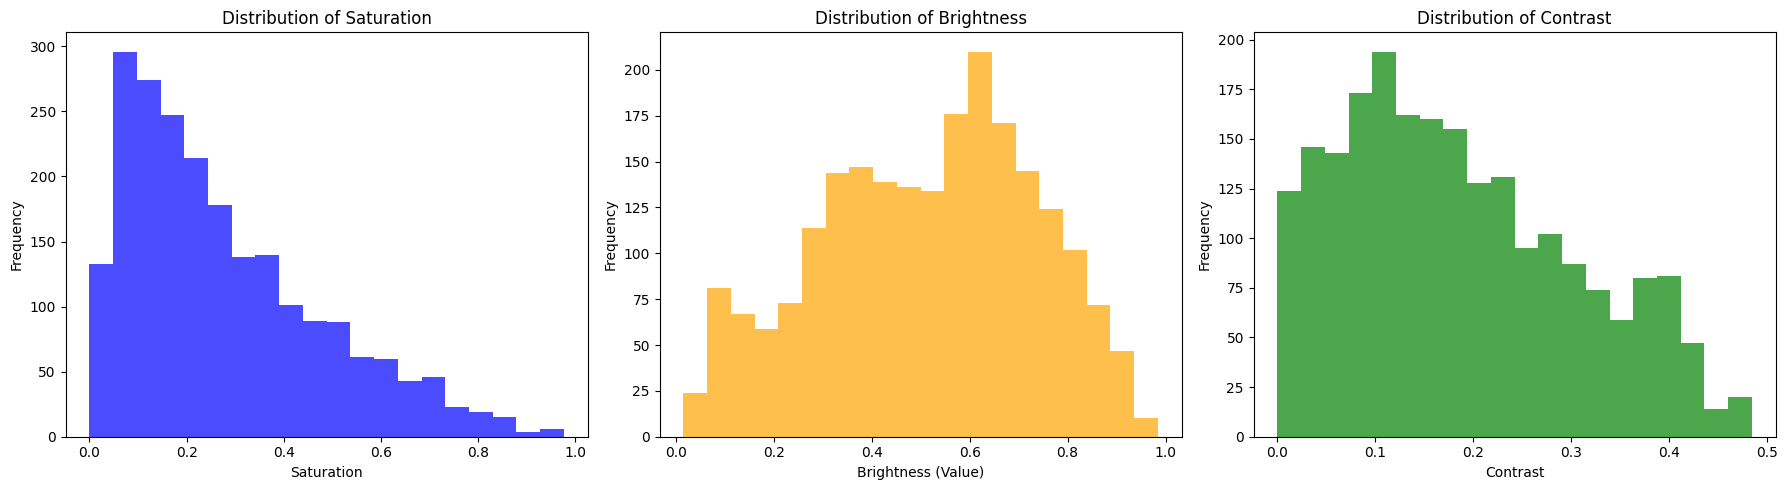

In [36]:

# Plot the distribution of saturation
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(saturation_values, bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Saturation')
plt.xlabel('Saturation')
plt.ylabel('Frequency')

# Plot the distribution of brightness
plt.subplot(1, 3, 2)
plt.hist(brightness_values, bins=20, color='orange', alpha=0.7)
plt.title('Distribution of Brightness')
plt.xlabel('Brightness (Value)')
plt.ylabel('Frequency')

# Plot the distribution of contrast
plt.subplot(1, 3, 3)
plt.hist(contrast_values, bins=20, color='green', alpha=0.7)
plt.title('Distribution of Contrast')
plt.xlabel('Contrast')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Saturation Distribution: The distribution is skewed towards the lower end, with most colors having low saturation. This suggests that many of the colors in these films are muted or desaturated, likely contributing to a more subdued or realistic visual tone.

Brightness Distribution: The brightness distribution is somewhat normally distributed but leans slightly towards the higher end. This indicates that while the films contain a range of brightness levels, there's a tendency towards brighter imagery, potentially reflecting more daylight or well-lit scenes.

Contrast Distribution: The contrast distribution shows that most colors have medium to low contrast, with a peak around the middle. This suggests that these films often employ a balanced contrast, avoiding extremes of very high or low contrast, which can create a more natural or visually comfortable viewing experience.

### Distribution of Color Temperature

Sample of color temperature values:
Color RGB([163.62162162 176.56756757 191.97297297]) -> Color Temperature: 4777.64 K
Color RGB([77.04761905 67.06349206 57.26984127]) -> Color Temperature: 5155.12 K
Color RGB([134.51724138 133.17241379 124.37931034]) -> Color Temperature: 5079.51 K
Color RGB([43.54666667 38.70666667 36.4       ]) -> Color Temperature: 5056.05 K
Color RGB([81.15517241 86.4137931  85.86206897]) -> Color Temperature: 4963.08 K
Color RGB([198.1        212.06666667 208.3       ]) -> Color Temperature: 4920.00 K
Color RGB([160.3   143.925 133.05 ]) -> Color Temperature: 5213.73 K
Color RGB([111.38596491  91.63157895  81.12280702]) -> Color Temperature: 5237.36 K
Color RGB([131.30555556 144.91666667 182.94444444]) -> Color Temperature: 4594.99 K
Color RGB([102.61403509 113.59649123 115.29824561]) -> Color Temperature: 4900.52 K


/var/folders/m7/r7m7ht2j7jbfb00kv5p9d0q00000gn/T/ipykernel_81186/4230416526.py:27: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



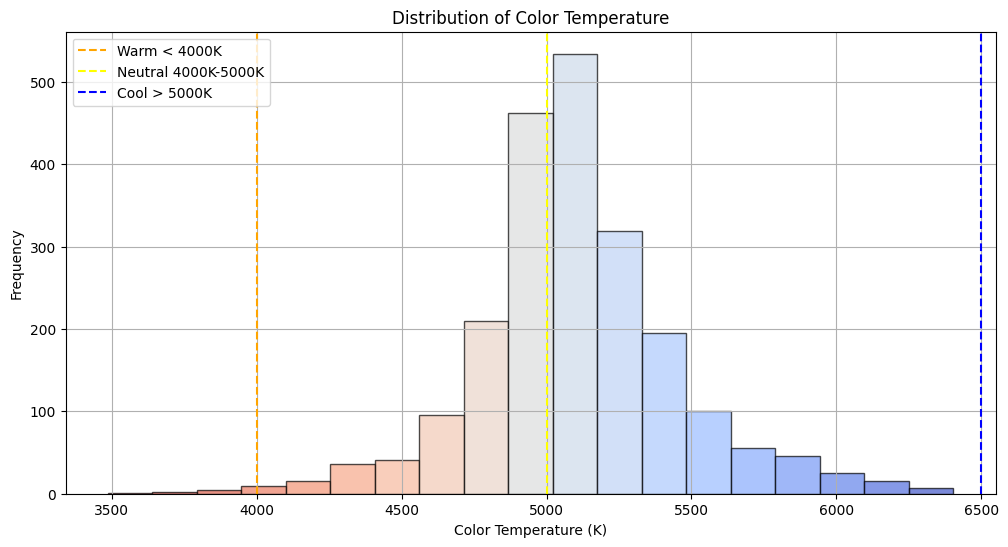

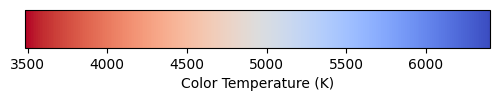

In [37]:

def calculate_color_temperature(r, g, b):
    # Approximate color temperature calculation (based on RGB)
    # This is a simplified model; more complex models use chromaticity calculations
    if r > b:
        # Warmer colors
        temperature = 5000 + (r - b) * 2000 / 255
    else:
        # Cooler colors
        temperature = 5000 - (b - r) * 2000 / 255
    return temperature

# Apply to all cluster centers
color_temperatures = [calculate_color_temperature(r, g, b) for r, g, b in all_cluster_centers]

# Print a sample to verify
print("Sample of color temperature values:")
for i in range(10):
    print(f"Color RGB({all_cluster_centers[i]}) -> Color Temperature: {color_temperatures[i]:.2f} K")

# Define temperature ranges
warm_threshold = 4000  # Below 4000K: warm
neutral_threshold = 5000  # 4000K-5000K: neutral
cool_threshold = 6500  # 5000K-6500K: cool
bins = np.linspace(min(color_temperatures), max(color_temperatures), 20)

# Create a reversed colormap for correct color temperature mapping
colormap = cm.get_cmap('coolwarm_r')  # Reverse the colormap to match color temperature convention
norm = plt.Normalize(min(color_temperatures), max(color_temperatures))

# Calculate the histogram data
hist, bin_edges = np.histogram(color_temperatures, bins=bins)

# Get the colors for each bin based on the average temperature in that bin
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
colors = [colormap(norm(center)) for center in bin_centers]

# Plot each bar manually with its corresponding color
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, hist, width=np.diff(bin_edges), color=colors, edgecolor='black', alpha=0.7)

plt.title('Distribution of Color Temperature')
plt.xlabel('Color Temperature (K)')
plt.ylabel('Frequency')

# Annotate ranges
plt.axvline(x=warm_threshold, color='orange', linestyle='--', label='Warm < 4000K')
plt.axvline(x=neutral_threshold, color='yellow', linestyle='--', label='Neutral 4000K-5000K')
plt.axvline(x=cool_threshold, color='blue', linestyle='--', label='Cool > 5000K')

plt.legend(loc='upper left')
plt.grid(True)

# Create a standalone colorbar that matches the colormap
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=colormap), cax=ax, orientation='horizontal')
cbar.set_label('Color Temperature (K)')
plt.show()



The distribution of color temperature is more varied, with significant portions falling into both the neutral (around 5000K) and cool (above 5000K) categories.

There's a notable peak around the 5000K range, indicating a preference for neutral to cool lighting in the scenes. This might suggest that Korean romance films utilize a mix of natural and slightly cool lighting, contributing to a more emotionally resonant and visually consistent atmosphere.

### Scatter Plots of Saturation vs. Brightness with Color Temperature and Contrast

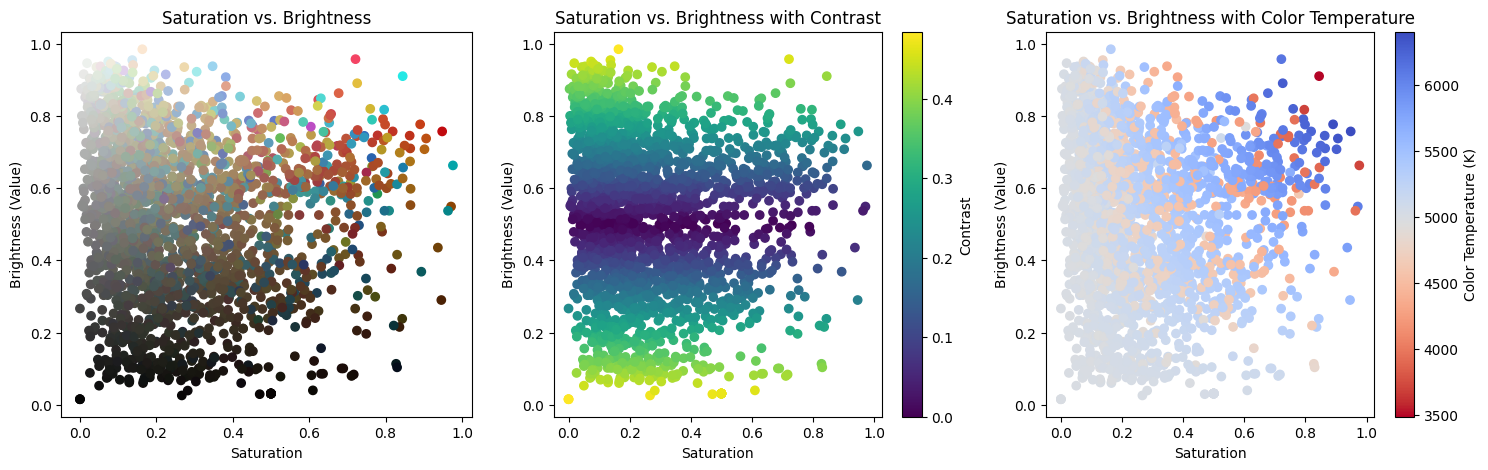

In [38]:
plt.figure(figsize=(18, 5))

# Scatter plot of saturation vs. brightness
# plt.figure(figsize=(7, 7))
plt.subplot(1,3,1)
plt.scatter(saturation_values, brightness_values, c=[mcolors.to_hex([r/255, g/255, b/255]) for r, g, b in all_cluster_centers], alpha=1)
plt.title('Saturation vs. Brightness')
plt.xlabel('Saturation')
plt.ylabel('Brightness (Value)')

# Scatter plot of Saturation vs. Brightness with Contrast as color
#plt.figure(figsize=(7, 7))
plt.subplot(1,3,2)
plt.scatter(saturation_values, brightness_values, c=contrast_values, cmap='viridis', alpha=1)
plt.colorbar(label='Contrast')
plt.title('Saturation vs. Brightness with Contrast')
plt.xlabel('Saturation')
plt.ylabel('Brightness (Value)')

# Scatter plot of Saturation vs. Brightness with Color Temperature as color
plt.subplot(1,3,3)
plt.scatter(saturation_values, brightness_values, c=color_temperatures, cmap='coolwarm_r', alpha=1)
plt.colorbar(label='Color Temperature (K)')
plt.title('Saturation vs. Brightness with Color Temperature')
plt.xlabel('Saturation')
plt.ylabel('Brightness (Value)')


plt.show()

Saturation vs. Brightness: The plot shows a wide spread, with many colors clustering in the lower saturation and mid to high brightness range. This further supports the observation that Korean films tend to use more muted, bright colors, possibly to evoke certain emotional tones without overwhelming the viewer with vivid colors.

Saturation vs. Brightness with Contrast: This plot highlights that most colors with higher saturation tend to have lower contrast, and those with higher brightness exhibit a balanced contrast. This balance suggests a careful use of contrast to maintain visual clarity without overshadowing the color palette.

Saturation vs. Brightness with Color Temperature: Colors with higher saturation generally correspond to cooler temperatures (blues), while warmer colors (reds, oranges) tend to be less saturated. This might indicate a deliberate choice to use cool, saturated colors to convey particular emotions or atmospheres in the films.

### Feature Clustering

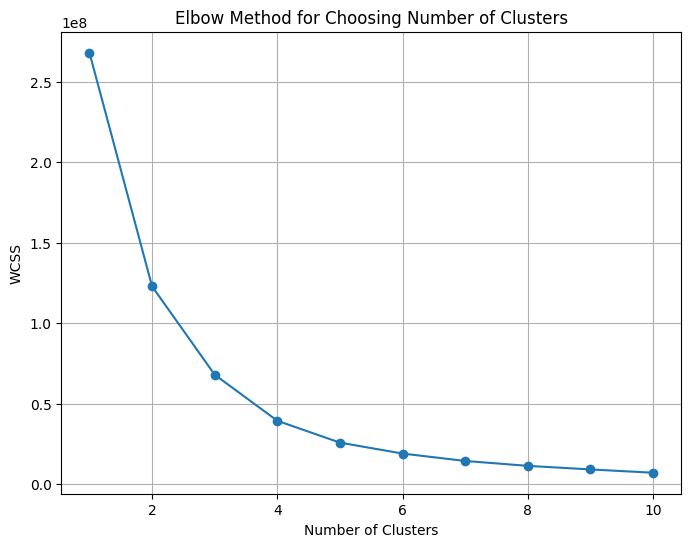

In [39]:
# Combine the features into a single dataset
combined_filter_data = np.column_stack((saturation_values, brightness_values, color_temperatures, contrast_values))

# Calculate WCSS for a range of cluster numbers
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(combined_filter_data)
    wcss.append(kmeans.inertia_)

# Plot the WCSS to find the elbow point
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Choosing Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [40]:
# Perform K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(combined_filter_data)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



### 3D Clustering of Saturation, Brightness, and Color Temperature

In [41]:
# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=combined_filter_data[:, 0],  # Saturation
    y=combined_filter_data[:, 1],  # Brightness
    z=combined_filter_data[:, 2],  # Color Temperature
    mode='markers',
    marker=dict(
        size=5,
        color=clusters,  # Color points by cluster
        colorscale='Viridis',  # Color scale
        opacity=0.8
    )
)])

# Add labels and title
fig.update_layout(
    title='3D Clustering of Saturation, Brightness, and Color Temperature',
    scene=dict(
        xaxis_title='Saturation',
        yaxis_title='Brightness',
        zaxis_title='Color Temperature'
    ),
    width=1000,  # Set the width of the plot
    height=700   # Set the height of the plot
)

# Display the plot
fig.show()


**Why Brightness is Not Included:** In this 3D plot, brightness was not chosen as one of the axes because it is highly correlated with saturation and color temperature. Including it might not provide additional insights and could make the clusters harder to interpret.

The 3D scatter plot reveals clear cluster separations based on the combination of these three features:

Cluster 0 (Purple): Represents colors with low saturation, medium brightness, and neutral color temperature.

Cluster 1 (Blue/Teal): Medium saturation, medium brightness, cool color temperature.

Cluster 2 (Green): Medium saturation, high brightness, neutral color temperature.

Cluster 3 (Yellow): High saturation, high brightness, cool color temperature.

The distinct clustering suggests that there are several dominant visual styles or "filters" used in these films, each characterized by a unique combination of these three features.

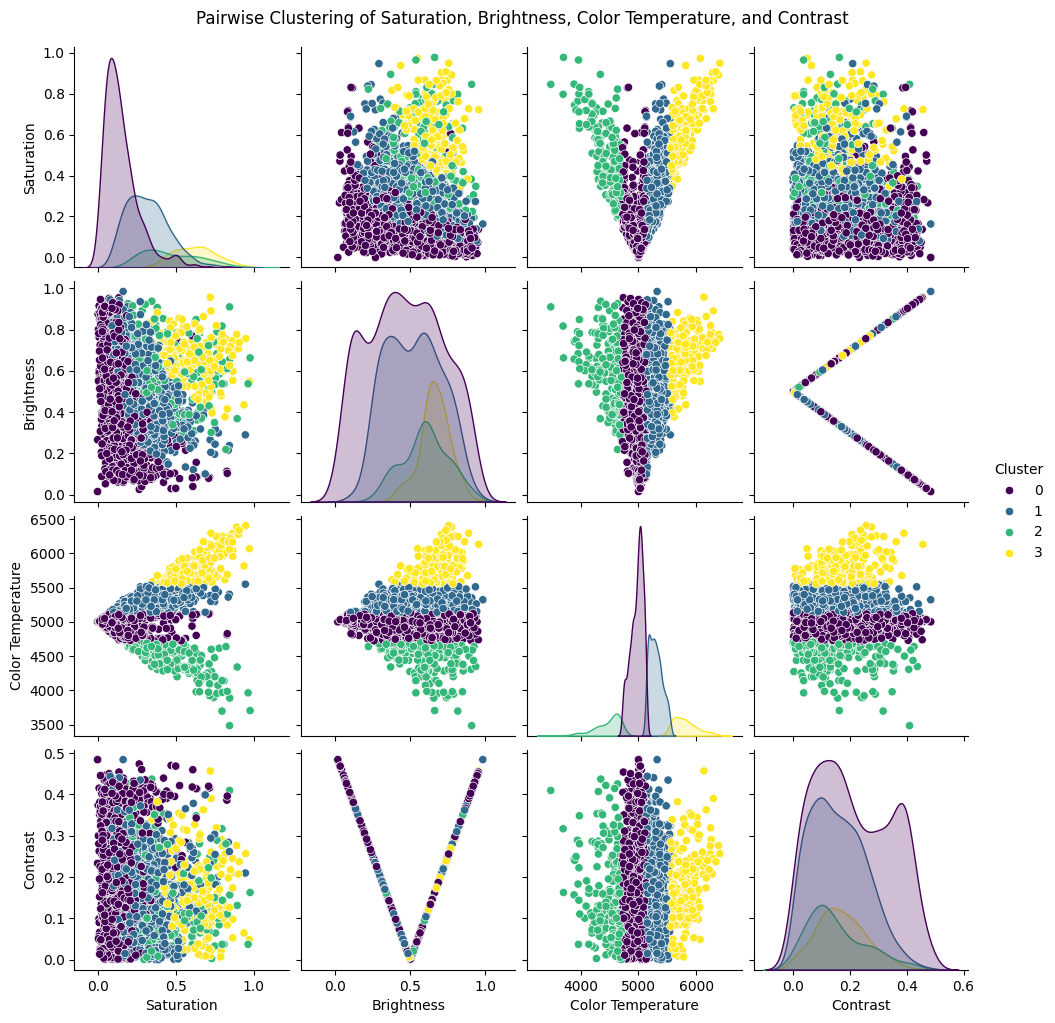

In [42]:
# Create a DataFrame for easier plotting
filters_df = pd.DataFrame({
    'Saturation': saturation_values,
    'Brightness': brightness_values,
    'Color Temperature': color_temperatures,
    'Contrast': contrast_values,
    'Cluster': clusters
})

# Pairplot to visualize relationships
sns.pairplot(filters_df, hue='Cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Pairwise Clustering of Saturation, Brightness, Color Temperature, and Contrast', y=1.02)
plt.show()


### Understanding the Pairplot
#### Diagonals: Kernel Density Estimations (KDEs)

- The diagonals show the distribution of each feature (Saturation, Brightness, Color Temperature, and Contrast) within each cluster. Each diagonal subplot uses a Kernel Density Estimation (KDE) to smooth out the distribution, providing an estimate of the probability density function for the feature within each cluster.

#### Off-Diagonal Plots: Pairwise Relationships

- For the off diagonals, what we're really seeing is that color temperature is the best feature for grouping colors into similar clusters, but since we havent sorted the colors by segment this really doesnt tell us much more


### What are the Cluster's Average Values

In [43]:
def categorize_value(value, feature):
    if feature == 'Saturation' or feature == 'Brightness':
        if value < 0.3:
            return 'Low'
        elif value < 0.6:
            return 'Medium'
        else:
            return 'High'
    elif feature == 'Color Temperature':
        if value < 4000:
            return 'Warm'
        elif value < 5000:
            return 'Neutral'
        else:
            return 'Cool'
    elif feature == 'Contrast':
        if value < 0.2:
            return 'Low'
        elif value < 0.4:
            return 'Medium'
        else:
            return 'High'

# Calculate the mean values for each cluster
cluster_means = filters_df.groupby('Cluster').mean()

# Print the results
print("Average Values for Each Cluster:")
print(cluster_means)

# Apply the categorization
categorized_means = cluster_means.apply(lambda col: [categorize_value(val, col.name) for val in col])
print("")
# Print the human-interpretable results
print("Human-Interpretable Average Values for Each Cluster:")
print(categorized_means)

Average Values for Each Cluster:
         Saturation  Brightness  Color Temperature  Contrast
Cluster                                                     
0          0.152747    0.465709        4969.606971  0.211366
1          0.321556    0.521855        5297.081246  0.157921
2          0.471218    0.599284        4461.680218  0.152605
3          0.624032    0.662183        5808.064920  0.170355

Human-Interpretable Average Values for Each Cluster:
        Saturation Brightness Color Temperature Contrast
Cluster                                                 
0              Low     Medium           Neutral   Medium
1           Medium     Medium              Cool      Low
2           Medium     Medium           Neutral      Low
3             High       High              Cool      Low


1. Cluster 0:

    - Low saturation, medium brightness, neutral color temperature, medium contrast. Likely used for more subdued, realistic scenes.

2. Cluster 1:

    - Medium saturation, medium brightness, cool color temperature, low contrast. Indicates a style that might emphasize cooler, moody visuals.

3. Cluster 2:

    -  Medium saturation, medium brightness, neutral color temperature, low contrast. Suggests a balanced, natural look, possibly for more relatable, everyday scenes.

4. Cluster 3:

    - High saturation, high brightness, cool color temperature, low contrast. Likely used for more dramatic, visually striking scenes.

**Must Keep in mind that while i can group these colors into certain clusters i cannot make assumptions about whether they actually represent certain segments of the film as ive not done this in a segmented format. To achieve that id need to do a clustering on specific segments of the film rather than as a whole**

### Final K-Means Clustering

Lets now do a K_Means analysis on all of our colors (that we got using K_Means on each segment of each movie) to get a set of 15/20 colors to represent english film.

In [44]:
# Define the number of final clusters 
final_num_clusters = 30

# Perform the final K-Means clustering on the combined cluster centers
final_kmeans = KMeans(n_clusters=final_num_clusters, n_init=10, random_state=42)
final_kmeans.fit(all_cluster_centers)

# Get the final cluster centers (representing the dominant colors)
final_colors = final_kmeans.cluster_centers_

### Visualization

In [45]:
# Convert RGB values to HEX
final_hex_colors = [mcolors.to_hex([r/255, g/255, b/255]) for r, g, b in final_colors]

# Optional: Sort the final colors by hue to make them more visually organized
hsv_colors = [mcolors.rgb_to_hsv([r/255, g/255, b/255]) for r, g, b in final_colors]
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_final_hex_colors = [final_hex_colors[i] for i in sorted_indices]

# Set the number of columns for the grid display
num_columns = 5  # Adjust as needed

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_final_hex_colors) / num_columns)

# Create an HTML table with a grid layout
html_table = '<table style="border-collapse: collapse;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_final_hex_colors):
            hex_color = sorted_final_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:50px; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'

# Display the HTML table with the final colors
display(HTML(html_table))

,#ba5f5c,,#a85232,,#0f0c0b,,#7a4722,,#483829
,#8b765f,,#766048,,#5a4b39,,#a78a64,,#1d1b18
,#302d29,,#ac9f82,,#c3b595,,#c3a84e,,#ceccb7
,#8a8a7f,,#849942,,#636860,,#d9e1db,,#aeb8b4
,#4e5451,,#9aa19e,,#40b1b8,,#687779,,#becdd0
,#328396,,#375a64,,#324348,,#718e9a,,#8aabc0
